In [18]:
import joblib
from pathlib import Path
from credit_risk.features import prep_one_split, DROP_COLS, NUMERICAL_COLS, CATEGORICAL_COLS
from credit_risk.dataset import load_splits, AFTER_EDA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [2]:
DROP_COLS.remove('issue_d')

In [3]:
train_df, val_df, test_df, _ = load_splits(AFTER_EDA)

2026-06-16 09:05:32.493 | INFO     | credit_risk.dataset:load_splits:263 - Checking if the files exists...
2026-06-16 09:05:32.501 | INFO     | credit_risk.dataset:load_splits:265 - Loading the Cached files...
2026-06-16 09:05:32.989 | INFO     | credit_risk.dataset:load_splits:273 - Loaded sucessfully all the splits and the metadata, Train_df shape: (466042, 110), val_df shape: (420204, 110), test_df shape: (431712, 110)


In [4]:
filtered_train_df, y_train = prep_one_split(df=train_df, drop_cols=DROP_COLS)
filtered_val_df, y_val = prep_one_split(df=val_df, drop_cols=DROP_COLS)
filtered_test_df, y_test = prep_one_split(df=test_df, drop_cols=DROP_COLS)

2026-06-16 09:05:47.256 | INFO     | credit_risk.features:prep_one_split:207 - Inside Function: prep_one_split
2026-06-16 09:05:47.256 | INFO     | credit_risk.features:split_target_and_features:143 - Inside Function: split_target_and_features
2026-06-16 09:05:47.256 | INFO     | credit_risk.features:split_target_and_features:144 - Splitting the target and the features...
2026-06-16 09:05:47.268 | INFO     | credit_risk.features:split_target_and_features:147 - features and target are splitted successfully...
2026-06-16 09:05:47.268 | INFO     | credit_risk.features:add_credit_yrs:160 - Inside Function: add_credit_yrs
2026-06-16 09:05:47.268 | INFO     | credit_risk.features:add_credit_yrs:162 - Adding the feature 'credit_yrs'
2026-06-16 09:05:47.277 | INFO     | credit_risk.features:add_credit_yrs:164 - 'credit_age_yrs added successfully!'
2026-06-16 09:05:47.277 | INFO     | credit_risk.features:add_fico_mid:169 - Inside Function: add_fico_mid
2026-06-16 09:05:47.277 | INFO     | cred

In [6]:
issue_d_train = filtered_train_df['issue_d']
sort_idx = issue_d_train.sort_values().index
filtered_train_df = filtered_train_df.loc[sort_idx]
y_train = y_train.loc[sort_idx]
issue_d_train = issue_d_train.loc[sort_idx]

In [7]:
issue_d_val = filtered_val_df['issue_d']
sort_idx = issue_d_val.sort_values().index
filtered_val_df = filtered_val_df.loc[sort_idx]
y_val = y_val.loc[sort_idx]
issue_d_val = issue_d_val.loc[sort_idx]

In [8]:
issue_d_test = filtered_test_df['issue_d']
sort_idx = issue_d_test.sort_values().index
filtered_test_df = filtered_test_df.loc[sort_idx]
y_test = y_test.loc[sort_idx]
issue_d_test = issue_d_test.loc[sort_idx]

In [10]:
num_pipeline = Pipeline([
    ('inpute', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [11]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUMERICAL_COLS),
    ('cat', cat_pipeline,CATEGORICAL_COLS),
], remainder='drop')

In [12]:
preprocessor.fit(filtered_train_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [13]:
X_train_feat = preprocessor.transform(filtered_train_df)
X_val_feat = preprocessor.transform(filtered_val_df)
X_test_feat = preprocessor.transform(filtered_test_df)

In [14]:
cwd = Path.cwd()
project_root = cwd.parent
model_path = project_root / 'models' / 'tuned_xgb' / 'model.pkl'
tuned_xgb_model = joblib.load(model_path)

In [20]:
val_proba = tuned_xgb_model[1].predict_proba(X_val_feat)[:, 1]

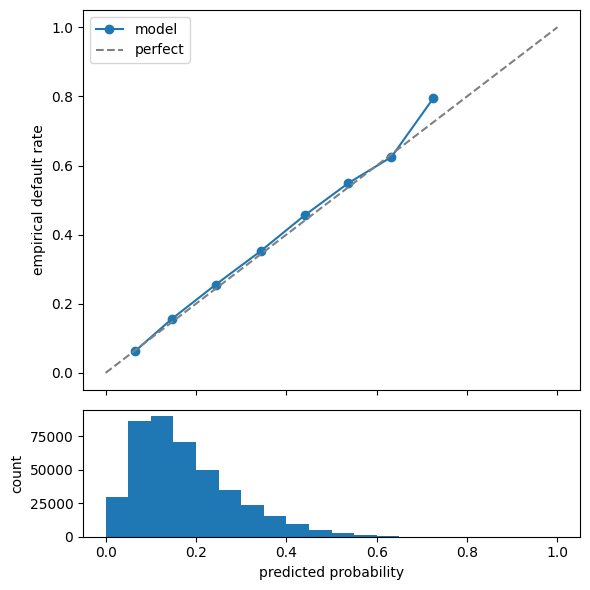

In [21]:
prob_true, prob_pred = calibration_curve(y_val.to_numpy(), val_proba, n_bins=10)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, height_ratios=[3, 1], figsize=(6, 6)
)

# top: reliability curve
ax1.plot(prob_pred, prob_true, marker="o", label="model")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax1.set_ylabel("empirical default rate")
ax1.legend()

# bottom: where the predicted mass actually sits
ax2.hist(val_proba, bins=20, range=(0, 1))
ax2.set_xlabel("predicted probability")
ax2.set_ylabel("count")

plt.tight_layout()
plt.show()

In [22]:
prob_true

array([0.06392906, 0.15549661, 0.25566763, 0.35225278, 0.45571049,
       0.54917582, 0.62452107, 0.79487179])

In [23]:
prob_pred

array([0.06606943, 0.14600824, 0.243954  , 0.34303787, 0.44043595,
       0.53729529, 0.63250266, 0.72545349])